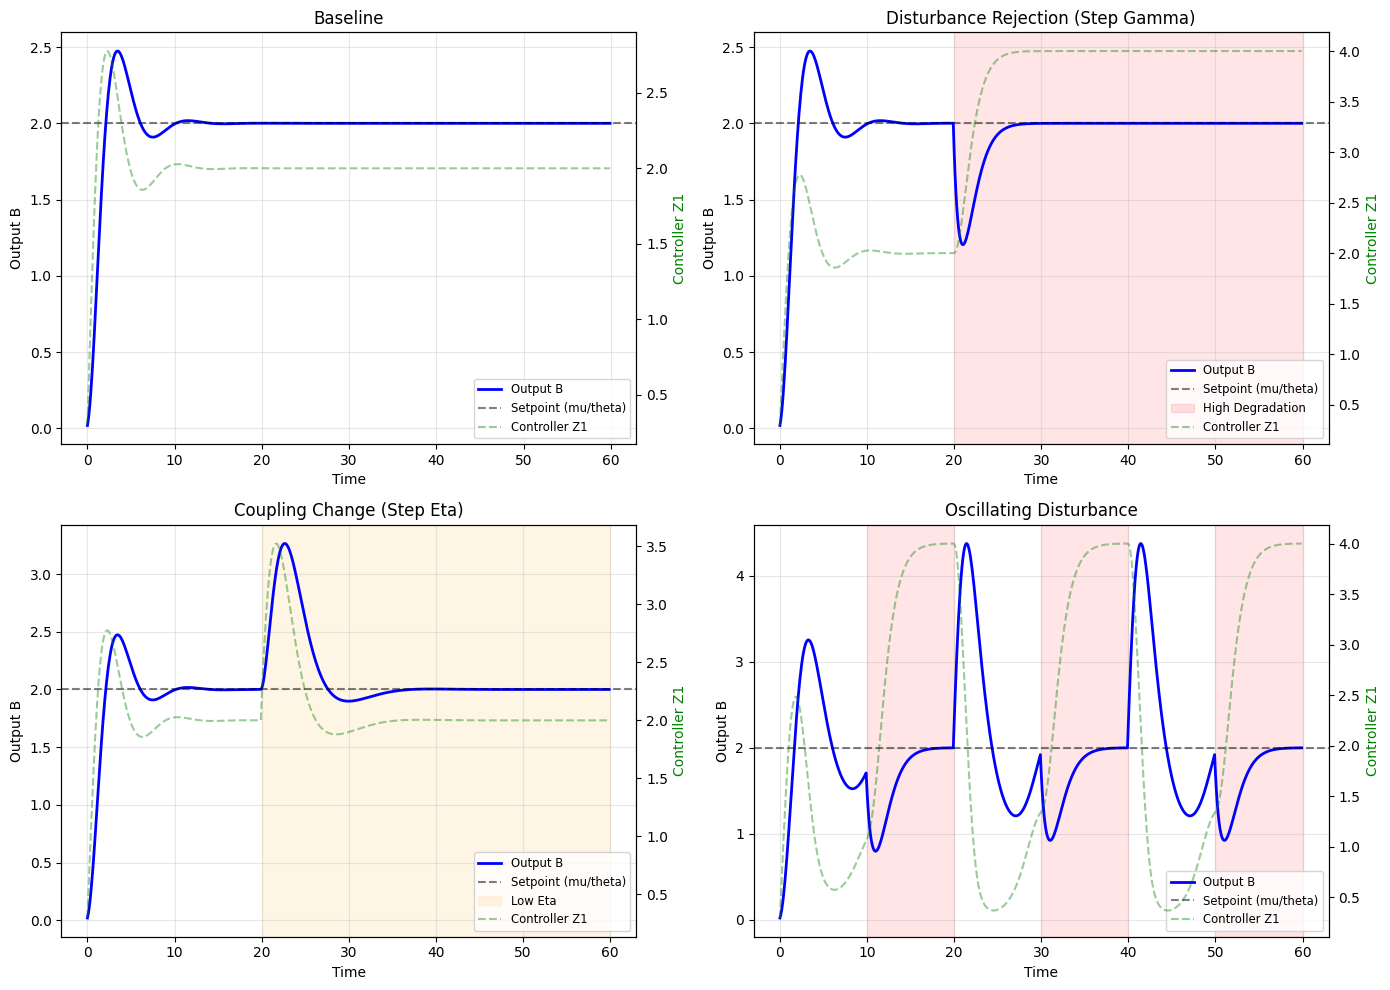

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --- 1. Define the System Class (Modified for Standalone Use) ---
class Antithetic:
    def __init__(self, fixed_params=None):
        # Default: mu=2.0, eta=2.0, theta=1.0, gamma=1.0
        # Target Setpoint B_ss = mu / theta = 2.0 / 1.0 = 2.0
        if fixed_params is None:
            self.fixed_params = torch.tensor([2.0, 2.0, 1.0, 1.0])
        else:
            self.fixed_params = fixed_params

    def forward_numpy(self, x, t, u):
        """Wrapper for scipy.odeint that handles the control inputs."""
        # Unpack state
        Z1, Z2, B = x
        
        # Unpack params
        mu, eta_base, theta, gamma_base = self.fixed_params.numpy()
        
        # Apply Control Inputs
        # u[0] scales eta (annihilation)
        # u[1] scales gamma (degradation)
        eta = u[0] * eta_base
        gamma = u[1] * gamma_base
        
        # Equations
        annihilation = eta * Z1 * Z2
        
        dZ1_dt = mu - annihilation
        dZ2_dt = theta * B - annihilation
        dB_dt  = Z1 - gamma * B
        
        return [dZ1_dt, dZ2_dt, dB_dt]

# --- 2. Simulation Helper ---
def simulate_schedule(name, time_points, control_schedule_fn):
    model = Antithetic()
    
    # Initial State: Start near zero
    x0 = [0.1, 0.1, 0.0]
    
    # We integrate step-by-step to allow dynamic control updates
    trajectory = []
    t_history = []
    u_history = []
    
    x_current = x0
    dt = time_points[1] - time_points[0]
    
    for t in time_points:
        # Get control vector for this moment
        u_t = control_schedule_fn(t)
        
        # Solve for one step
        # We pass u_t as an arg to the wrapper
        sol = odeint(model.forward_numpy, x_current, [t, t+dt], args=(u_t,))
        
        # Update state
        x_next = sol[-1]
        x_current = x_next
        
        # Store
        trajectory.append(x_current)
        t_history.append(t)
        u_history.append(u_t)
        
    return np.array(t_history), np.array(trajectory), np.array(u_history)

# --- 3. Define Scenarios ---

# Scenario A: Baseline (Fixed Control u=[1,1])
def schedule_baseline(t):
    return [1.0, 1.0]

# Scenario B: Disturbance (Step Change in Gamma at t=20)
# This tests "Perfect Adaptation". B should return to setpoint.
def schedule_disturbance(t):
    if t < 20:
        return [1.0, 1.0]  # Normal gamma
    else:
        return [1.0, 2.0]  # Double gamma (heavy load)

# Scenario C: Parameter Switch (Step Change in Eta at t=20)
# This tests dynamic stability. 
def schedule_eta_switch(t):
    if t < 20:
        return [1.0, 1.0] # Normal coupling
    else:
        return [0.1, 1.0] # Weak coupling (expect oscillations)

# Scenario D: Oscillating Disturbance (Switched Gamma)
# Toggles load every 10 seconds.
def schedule_switched(t):
    # Switch every 10 seconds
    if (t // 10) % 2 == 0:
        return [1.0, 0.5]
    else:
        return [1.0, 2.0]

# --- 4. Run & Plot ---
time = np.arange(0, 60, 0.1)
scenarios = [
    ("Baseline", schedule_baseline),
    ("Disturbance Rejection (Step Gamma)", schedule_disturbance),
    ("Coupling Change (Step Eta)", schedule_eta_switch),
    ("Oscillating Disturbance", schedule_switched)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Theoretical Setpoint: B = mu / theta = 2.0 / 1.0 = 2.0
SETPOINT = 2.0

for ax, (name, schedule) in zip(axes, scenarios):
    t_sim, x_sim, u_sim = simulate_schedule(name, time, schedule)
    
    # Extract variables
    Z1 = x_sim[:, 0]
    Z2 = x_sim[:, 1]
    B  = x_sim[:, 2]
    
    # Plot B (Output)
    ax.plot(t_sim, B, 'b-', linewidth=2, label='Output B')
    ax.axhline(SETPOINT, color='k', linestyle='--', alpha=0.5, label='Setpoint (mu/theta)')
    
    # Plot Z1 (Controller) on twin axis to show adaptation effort
    ax_twin = ax.twinx()
    ax_twin.plot(t_sim, Z1, 'g--', alpha=0.4, label='Controller Z1')
    ax_twin.set_ylabel('Controller Z1', color='g')
    
    # Labels & Title
    ax.set_title(name)
    ax.set_xlabel('Time')
    ax.set_ylabel('Output B')
    ax.grid(True, alpha=0.3)
    
    # Visualize the control change region
    if "Step Gamma" in name:
        ax.axvspan(20, 60, color='red', alpha=0.1, label='High Degradation')
    elif "Step Eta" in name:
        ax.axvspan(20, 60, color='orange', alpha=0.1, label='Low Eta')
    elif "Oscillating" in name:
        # Shade the "High Gamma" regions
        for i in range(0, 60, 20): # 10s on, 10s off
            ax.axvspan(i+10, i+20, color='red', alpha=0.1)

    # Combine legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_twin.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize='small')

plt.tight_layout()
plt.show()